# Лабораторная работа №3
## Линейная регрессия

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Jupyter Notebook, окружение conda `lab1_terminal`.

**Цель работы:** изучение математических основ и практическое применение моделей парной
и множественной линейной регрессии с использованием `scikit-learn`, оценка качества моделей
с помощью метрик эффективности, эксперименты с различными комбинациями признаков.

---
# Часть 1. Наборы данных

Выбраны два набора данных, отличающиеся от использованных в ЛР №1 (Iris, Titanic) и ЛР №2
(Wine Quality, Adult):

| № | Набор данных | Файл | Задача |
|---|---|---|---|
| 1 | [Salary Data](https://www.kaggle.com/datasets/vihansp/salary-data) — зарплата от стажа работы | `data/Salary_Data.csv` | парная регрессия: `Salary` ~ `YearsExperience` |
| 2 | [Advertising](https://www.statlearning.com/resources-second-edition) (ISLR) — продажи от затрат на рекламу | `data/Advertising.csv` | множественная регрессия: `sales` ~ `TV`, `radio`, `newspaper` |

Модель линейной регрессии: $\hat{y} = w_0 + w_1x_1 + \dots + w_kx_k$, где $w_0$ — свободный
член (intercept), $w_1 \dots w_k$ — коэффициенты (веса) признаков. `LinearRegression` подбирает
веса методом наименьших квадратов — минимизирует сумму квадратов отклонений $\sum (y_i - \hat{y}_i)^2$.

Метрики качества на тестовой выборке:
* **MAE** $= \frac{1}{n}\sum|y_i - \hat{y}_i|$ — средняя абсолютная ошибка (в единицах целевой переменной);
* **MSE** $= \frac{1}{n}\sum(y_i - \hat{y}_i)^2$ — среднеквадратичная ошибка (сильнее штрафует большие ошибки);
* **R²** $= 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ — доля дисперсии целевой переменной, объяснённая моделью (1 — идеал).

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
TEST_SIZE, SEED = 0.2, 42   # разбиение 80/20, одинаковое для всех экспериментов

results = {}                # метрики всех моделей для итоговой таблицы


def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    results[name] = {"признаков": X_test.shape[1],
                     "MAE": mean_absolute_error(y_test, pred),
                     "MSE": mean_squared_error(y_test, pred),
                     "R2": r2_score(y_test, pred)}
    return pd.DataFrame.from_dict({name: results[name]}, orient="index").style.format(precision=4)

---
# Часть 2.1. Парная линейная регрессия — Salary Data

Набор из 30 записей: стаж работы в годах `YearsExperience` и годовая зарплата `Salary`.

## Аудит данных

In [2]:
salary = pd.read_csv(DATA_DIR / "Salary_Data.csv")
display(salary.head())
print("Размерность:", salary.shape)
salary.info()
print("\nПропуски:", salary.isna().sum().to_dict())
print("Дубликатов:", salary.duplicated().sum())

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Размерность: (30, 2)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes

Пропуски: {'YearsExperience': 0, 'Salary': 0}
Дубликатов: 0


,count,mean,std,min,25%,50%,75%,max
YearsExperience,30.0,5.313333,2.837888,1.1,3.20,4.7,7.70,10.5
Salary,30.0,76003.000000,27414.429785,37731.0,56720.75,65237.0,100544.75,122391.0


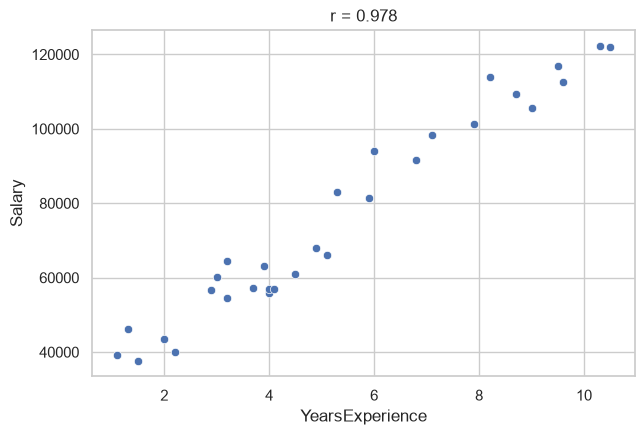

In [3]:
display(salary.describe().T)

plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=salary, x="YearsExperience", y="Salary")
plt.title(f"r = {salary['YearsExperience'].corr(salary['Salary']):.3f}")
plt.show()

Оба столбца числовые (`float64`), пропусков и дубликатов нет — предобработка не нужна.
Точки лежат почти на прямой (коэффициент корреляции ≈ 0.98), поэтому зависимость
хорошо описывается парной линейной регрессией.

## Обучение модели

In [4]:
X = salary[["YearsExperience"]]   # признак — двумерная таблица (n, 1), как требует sklearn
y = salary["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)
print("train:", X_train.shape, " test:", X_test.shape)

salary_model = LinearRegression().fit(X_train, y_train)
w1, w0 = salary_model.coef_[0], salary_model.intercept_
print(f"Коэффициент наклона (slope) w1 = {w1:.2f}")
print(f"Свободный член (intercept) w0 = {w0:.2f}")
print(f"Уравнение: Salary = {w0:.2f} + {w1:.2f} * YearsExperience")

train: (24, 1)  test: (6, 1)
Коэффициент наклона (slope) w1 = 9423.82
Свободный член (intercept) w0 = 25321.58
Уравнение: Salary = 25321.58 + 9423.82 * YearsExperience


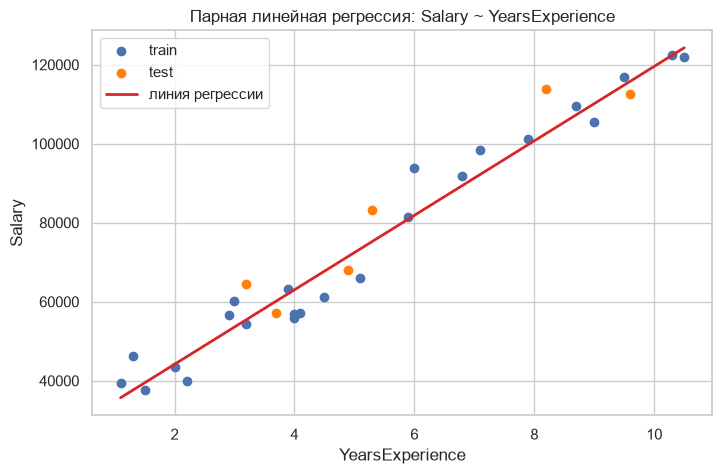

,признаков,MAE,MSE,R2
Salary: YearsExperience,1,6286.4538,49830096.8559,0.9024


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, color="tab:orange", label="test")
x_line = np.linspace(X["YearsExperience"].min(), X["YearsExperience"].max(), 100)
plt.plot(x_line, w0 + w1 * x_line, color="tab:red", lw=2, label="линия регрессии")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Парная линейная регрессия: Salary ~ YearsExperience")
plt.legend()
plt.show()

evaluate("Salary: YearsExperience", salary_model, X_test, y_test)

Уравнение модели: **Salary = 25321.58 + 9423.82 · YearsExperience** — каждый год стажа
в среднем добавляет к зарплате ≈ 9.4 тыс., а свободный член (≈ 25.3 тыс.) — прогноз
для нулевого стажа. Линия регрессии проходит через облако точек обеих выборок;
на тестовой выборке (6 объектов) R² ≈ 0.90, MAE ≈ 6.3 тыс. — около 8 % от средней зарплаты.

---
# Часть 2.2. Множественная линейная регрессия — Advertising

200 рынков: затраты на рекламу (тыс. $) на телевидении `TV`, радио `radio` и в газетах
`newspaper`, а также продажи товара `sales` (тыс. единиц). Первый столбец файла — номер
строки, он используется как индекс.

## Аудит данных

In [6]:
adv = pd.read_csv(DATA_DIR / "Advertising.csv", index_col=0)
display(adv.head())
print("Размерность:", adv.shape)
adv.info()
print("\nПропуски:", adv.isna().sum().to_dict())
print("Дубликатов:", adv.duplicated().sum())
display(adv.describe().T)

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Размерность: (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Пропуски: {'TV': 0, 'radio': 0, 'newspaper': 0, 'sales': 0}
Дубликатов: 0


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


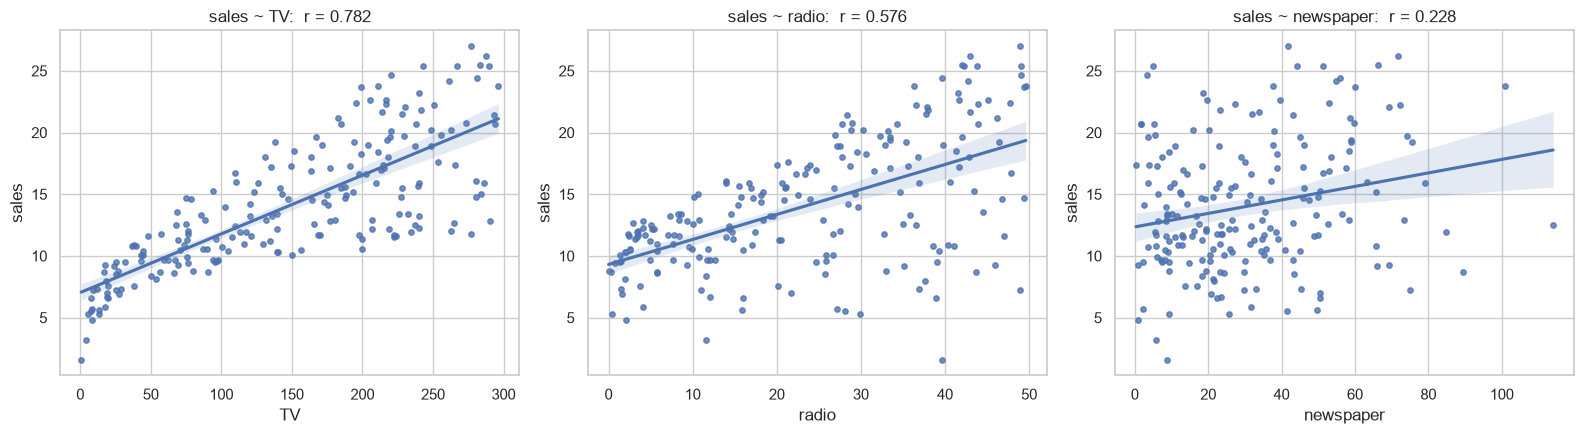

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["TV", "radio", "newspaper"]):
    sns.regplot(data=adv, x=col, y="sales", ax=ax, scatter_kws={"s": 15})
    ax.set_title(f"sales ~ {col}:  r = {adv[col].corr(adv['sales']):.3f}")
fig.tight_layout()
plt.show()

Все признаки числовые, пропусков и дубликатов нет. Сильнее всего с продажами связан
`TV` (r ≈ 0.78), затем `radio` (r ≈ 0.58); связь с `newspaper` слабая (r ≈ 0.23).
Отсюда порядок добавления признаков в экспериментах: **А** — `TV`, **Б** — `TV + radio`,
**В** — `TV + radio + newspaper`.

## Эксперименты с комбинациями признаков

Для каждого эксперимента выборка делится на train/test (80/20) с одним и тем же
`random_state`, поэтому все модели проверяются на одних и тех же объектах и их метрики сравнимы.

In [8]:
experiments = {
    "А": ["TV"],
    "Б": ["TV", "radio"],
    "В": ["TV", "radio", "newspaper"],
}
y = adv["sales"]
adv_models, adv_tests = {}, {}

for exp, features in experiments.items():
    X = adv[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)
    model = LinearRegression().fit(X_train, y_train)
    adv_models[exp] = model
    adv_tests[exp] = (X_test, y_test)

    terms = " + ".join(f"{w:.4f}*{f}" for f, w in zip(features, model.coef_))
    print(f"Эксперимент {exp}: sales = {model.intercept_:.4f} + {terms}")
    evaluate(f"Advertising {exp}: " + " + ".join(features), model, X_test, y_test)

pd.DataFrame.from_dict(results, orient="index").iloc[-3:].style.format(precision=4)

Эксперимент А: sales = 7.1196 + 0.0465*TV
Эксперимент Б: sales = 3.0283 + 0.0447*TV + 0.1907*radio
Эксперимент В: sales = 2.9791 + 0.0447*TV + 0.1892*radio + 0.0028*newspaper


,признаков,MAE,MSE,R2
Advertising А: TV,1,2.4444,10.2047,0.6767
Advertising Б: TV + radio,2,1.4443,3.1379,0.9006
Advertising В: TV + radio + newspaper,3,1.4608,3.1741,0.8994


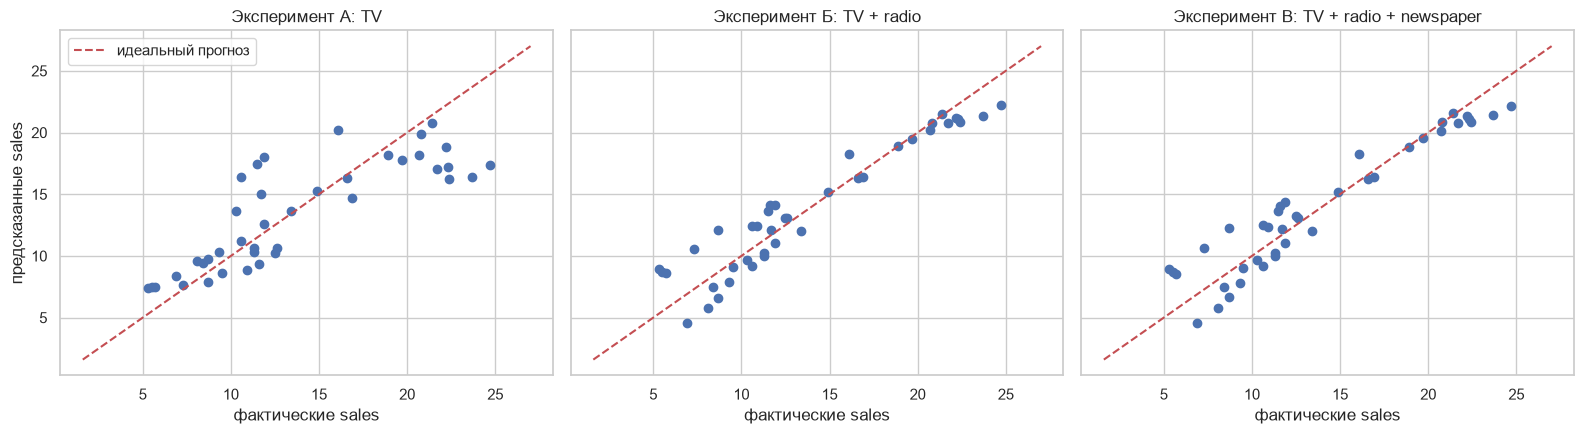

In [9]:
# Предсказания против фактических значений на тестовой выборке
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (exp, features) in zip(axes, experiments.items()):
    X_test, y_test = adv_tests[exp]
    ax.scatter(y_test, adv_models[exp].predict(X_test))
    ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="идеальный прогноз")
    ax.set_title(f"Эксперимент {exp}: " + " + ".join(features))
    ax.set_xlabel("фактические sales")
axes[0].set_ylabel("предсказанные sales")
axes[0].legend()
fig.tight_layout()
plt.show()

Модель полного набора признаков (эксперимент В) сохраняется в файл для Streamlit-приложения
(дополнительное задание):

In [10]:
joblib.dump(adv_models["В"], "advertising_model.joblib")
print("Модель сохранена: advertising_model.joblib")

Модель сохранена: advertising_model.joblib


---
# Часть 2.3. Сравнение моделей

In [11]:
metrics = pd.DataFrame.from_dict(results, orient="index")
metrics.style.format(precision=4)

,признаков,MAE,MSE,R2
Salary: YearsExperience,1,6286.4538,49830096.8559,0.9024
Advertising А: TV,1,2.4444,10.2047,0.6767
Advertising Б: TV + radio,2,1.4443,3.1379,0.9006
Advertising В: TV + radio + newspaper,3,1.4608,3.1741,0.8994


## Выводы

* **Парная регрессия (Salary Data).** Стаж объясняет ≈ 90 % дисперсии зарплаты на тесте
  (R² = 0.90). MAE и MSE измеряются в единицах целевой переменной, поэтому сравнивать их
  можно только между моделями одного набора данных; R² безразмерен.
* **Эксперимент А (`TV`).** Один самый сильный признак даёт R² ≈ 0.68 — заметная часть
  дисперсии продаж остаётся необъяснённой.
* **Эксперимент Б (`TV + radio`).** Добавление радио резко улучшает модель: MAE падает
  с 2.44 до 1.44, MSE — с 10.2 до 3.1, R² растёт до ≈ 0.90. Это лучшая модель по всем метрикам.
* **Эксперимент В (`TV + radio + newspaper`).** Добавление газет не улучшает качество
  (метрики даже чуть хуже, чем в Б): вес `newspaper` близок к нулю (≈ 0.003), а его
  корреляция с продажами объясняется в основном связью с `radio` (r ≈ 0.35).
  Увеличение числа признаков не гарантирует лучшей модели — неинформативный признак лишь
  добавляет шум.

---
# Часть 3. Дополнительное задание — Streamlit

Веб-приложение [`app_streamlit.py`](app_streamlit.py) загружает сохранённую модель
`advertising_model.joblib` (эксперимент В). В боковой панели ползунками задаются бюджеты
на `TV`, `radio` и `newspaper`; при каждом изменении приложение пересчитывает прогноз
продаж по уравнению регрессии и перестраивает график: зависимость прогноза от бюджета
выбранного канала при остальных фиксированных бюджетах, исходные данные и текущая точка прогноза.

Запуск:

```bat
conda activate lab1_terminal
streamlit run app_streamlit.py
```